In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageDraw


Task 2 comparison:
Do both functions give the same result? True


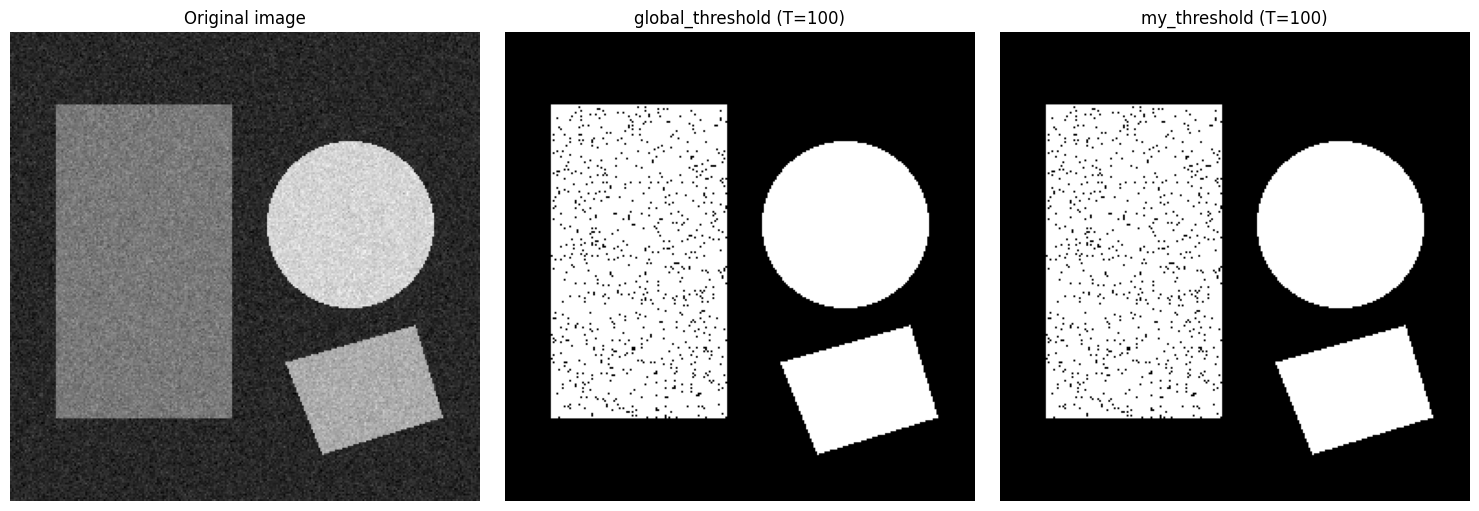

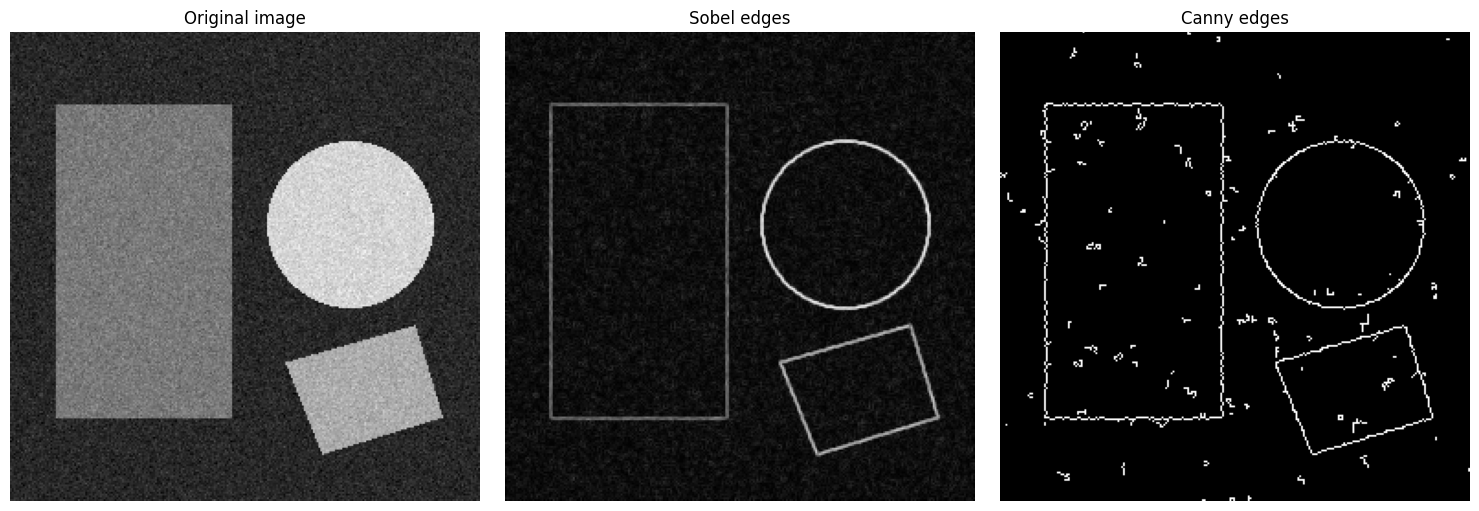


Challenge 3 answers:
Cleaner edges: Canny usually gives cleaner and thinner edges than Sobel.
More sensitive to noise: Sobel is usually more sensitive to noise because it responds directly to intensity changes without as much edge filtering.


In [11]:
# Task 2: Build Your Own Segmentation Function

def my_threshold(image, T):
    mask = np.zeros_like(image, dtype=np.uint8)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if image[i, j] >= T:
                mask[i, j] = 1
            else:
                mask[i, j] = 0

    return mask

T = 100
original_mask = global_threshold(image, T)
my_mask = my_threshold(image, T)

same_result = np.array_equal(original_mask, my_mask)
print("\nTask 2 comparison:")
print(f"Do both functions give the same result? {same_result}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(original_mask, cmap="gray")
axes[1].set_title(f"global_threshold (T={T})")
axes[1].axis("off")

axes[2].imshow(my_mask, cmap="gray")
axes[2].set_title(f"my_threshold (T={T})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# Challenge 3: Edge Detection Comparison

# Sobel edges using OpenCV
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_edges = cv2.magnitude(sobel_x, sobel_y)
sobel_edges = cv2.normalize(sobel_edges, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Canny edges using OpenCV
canny_edges = cv2.Canny(image, 100, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(sobel_edges, cmap="gray")
axes[1].set_title("Sobel edges")
axes[1].axis("off")

axes[2].imshow(canny_edges, cmap="gray")
axes[2].set_title("Canny edges")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("\nChallenge 3 answers:")
print("Cleaner edges: Canny usually gives cleaner and thinner edges than Sobel.")
print("More sensitive to noise: Sobel is usually more sensitive to noise because it responds directly to intensity changes without as much edge filtering.")

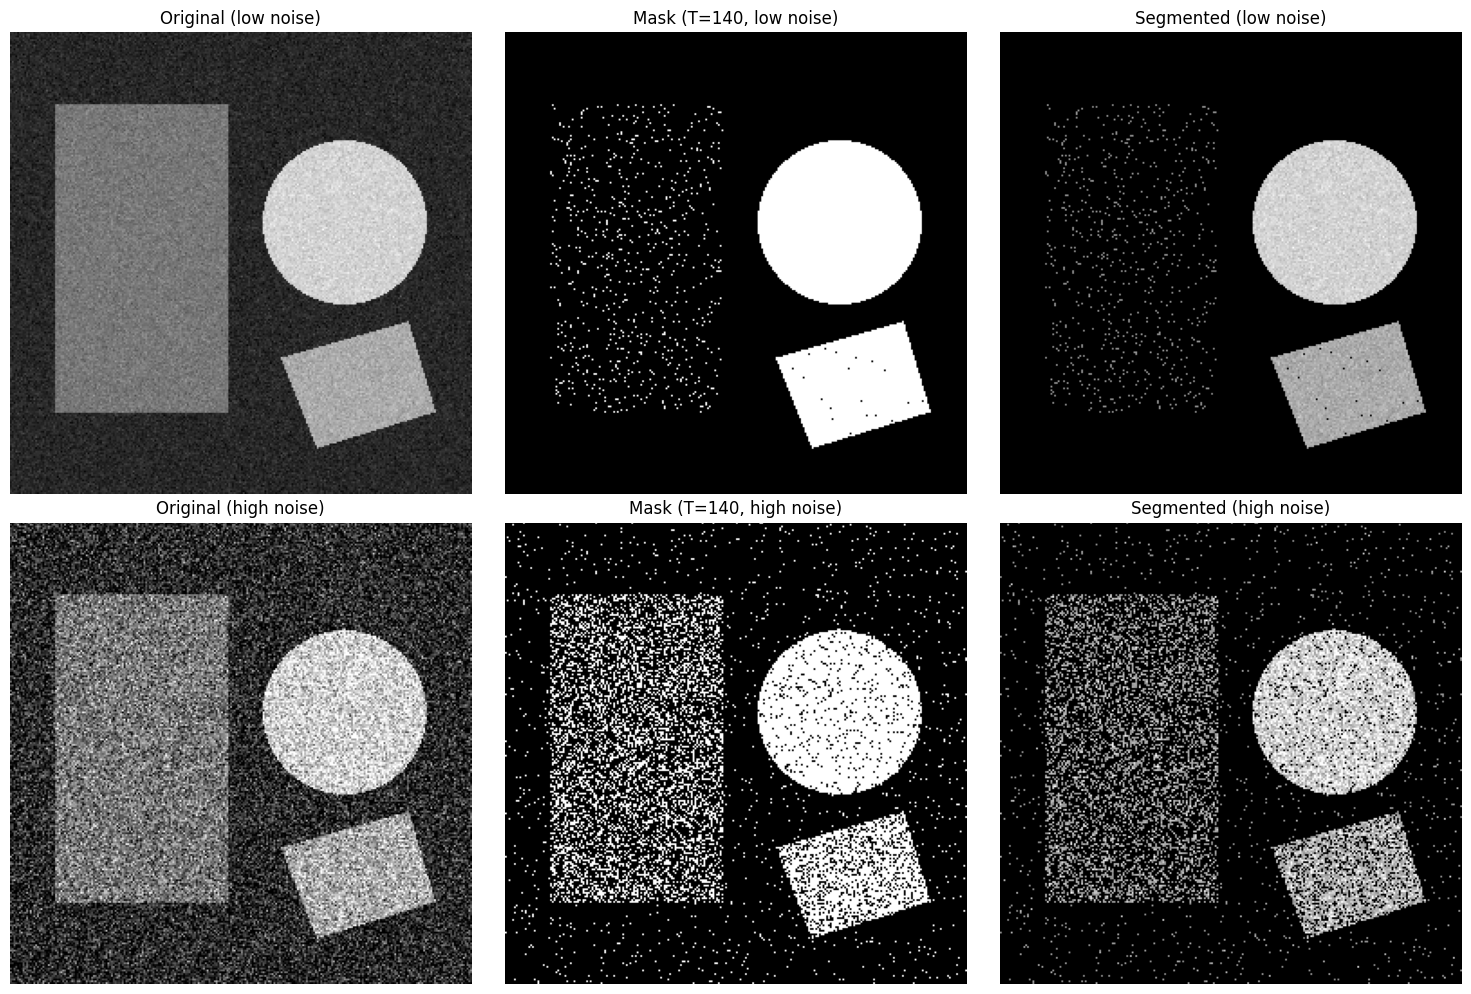

1. What happens to the mask?
   With higher noise, the mask becomes noisier. More background pixels are incorrectly included as foreground, and some object pixels may be missed due to noise fluctuations.

2. Does the same threshold still work?
   The same threshold works less effectively. The segmentation quality degrades because noise causes intensity variations that confuse the threshold.

3. What could you do to improve the result?
   - Apply Gaussian smoothing before thresholding to reduce noise.
   - Use adaptive thresholding instead of global thresholding.
   - Increase the threshold value slightly to compensate for noise.
   - Use morphological operations like opening to clean up the mask.


In [12]:
# Task 3: Noise Challenge

# First, create the original synthetic image with default noise
def create_synthetic_image(size=(256, 256), noise_level=12):
    width, height = size
    img = Image.new("L", size, color=40)  # dark background
    draw = ImageDraw.Draw(img)

    # medium rectangle
    draw.rectangle((25, 40, 120, 210), fill=120)

    # bright circle
    draw.ellipse((140, 60, 230, 150), fill=210)

    # slanted bright bar
    draw.polygon([(150, 180), (220, 160), (235, 210), (170, 230)], fill=170)

    arr = np.array(img).astype(np.float32)

    # add noise
    noise = np.random.normal(loc=0, scale=noise_level, size=arr.shape)
    arr = np.clip(arr + noise, 0, 255)

    return arr.astype(np.uint8)

# Original image with low noise
image_low_noise = create_synthetic_image(noise_level=12)

# Noisy image with high noise
image_high_noise = create_synthetic_image(noise_level=50)  # Increased noise

# Use the same threshold as before, e.g., T=140
T = 140

mask_low = global_threshold(image_low_noise, T)
mask_high = global_threshold(image_high_noise, T)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Low noise
axes[0, 0].imshow(image_low_noise, cmap="gray")
axes[0, 0].set_title("Original (low noise)")
axes[0, 0].axis("off")

axes[0, 1].imshow(mask_low, cmap="gray")
axes[0, 1].set_title(f"Mask (T={T}, low noise)")
axes[0, 1].axis("off")

axes[0, 2].imshow(image_low_noise * mask_low, cmap="gray")
axes[0, 2].set_title("Segmented (low noise)")
axes[0, 2].axis("off")

# Row 2: High noise
axes[1, 0].imshow(image_high_noise, cmap="gray")
axes[1, 0].set_title("Original (high noise)")
axes[1, 0].axis("off")

axes[1, 1].imshow(mask_high, cmap="gray")
axes[1, 1].set_title(f"Mask (T={T}, high noise)")
axes[1, 1].axis("off")

axes[1, 2].imshow(image_high_noise * mask_high, cmap="gray")
axes[1, 2].set_title("Segmented (high noise)")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Answers to questions:
print("1. What happens to the mask?")
print("   With higher noise, the mask becomes noisier. More background pixels are incorrectly included as foreground, and some object pixels may be missed due to noise fluctuations.")

print("\n2. Does the same threshold still work?")
print("   The same threshold works less effectively. The segmentation quality degrades because noise causes intensity variations that confuse the threshold.")

print("\n3. What could you do to improve the result?")
print("   - Apply Gaussian smoothing before thresholding to reduce noise.")
print("   - Use adaptive thresholding instead of global thresholding.")
print("   - Increase the threshold value slightly to compensate for noise.")
print("   - Use morphological operations like opening to clean up the mask.")